# Gridded COARDS NetCDF files

COARDS-convention rectilinear grids (packed int16 with scale/offset). Same workflow as the CF notebook: inspect, plot, retrieve, reduce, mutate, crop, save.

In [1]:
%matplotlib inline
import tempfile
from pathlib import Path

import geopandas as gpd
import numpy as np
from shapely.geometry import Polygon

from pyramids.dataset import Dataset
from pyramids.feature import FeatureCollection
from pyramids.netcdf import GeoReference, NetCDF

DATA = Path('../../../../examples/data/netcdf/samples')

## `coards__4v__1d3-3d1__y-desc.nc`

NCEP reanalysis air temperature on a 2.5° global grid (packed int16).

**Open the file and inspect the container**

In [2]:
nc = NetCDF.read_file(DATA / 'coards__4v__1d3-3d1__y-desc.nc')
nc

Driver: netCDF/Network Common Data Format
Files: ../../../../examples/data/netcdf/samples/coards__4v__1d3-3d1__y-desc.nc
Size is 512, 512
Corner Coordinates:
Upper Left  (    0.0,    0.0)
Lower Left  (    0.0,  512.0)
Upper Right (  512.0,    0.0)
Lower Right (  512.0,  512.0)
Center      (  256.0,  256.0)

**Dimensions and variables**

In [3]:
# get_all_metadata() returns a NetCDFMetadata whose summary lists dimensions and, for each
# variable, its dims / shape / dtype / unit / scale-offset.
meta = nc.get_all_metadata()
print(meta)

NetCDFMetadata
  Driver: netCDF
  Root group: /
  Dimensions (3):
    lat                  size=25
    lon                  size=53
    time                 size=100
  Variables (4):
    air dims=('/time', '/lat', '/lon') shape=(100, 25, 53) dtype=int16 unit='degK' scale=0.01 offset=None
    lat dims=('/lat',) shape=(25,) dtype=float32 unit='degrees_north'
    lon dims=('/lon',) shape=(53,) dtype=float32 unit='degrees_east'
    time dims=('/time',) shape=(100,) dtype=float32 unit='hours since 1800-01-01'
  Global attributes: Conventions, title, description, platform, references


**Global attributes**

In [4]:
nc.global_attributes

{'Conventions': 'COARDS',
 'title': '4x daily NMC reanalysis (1948)',
 'description': 'Data is from NMC initialized reanalysis\n(4x/day).  These are the 0.9950 sigma level values.',
 'platform': 'Model',
 'references': 'http://www.esrl.noaa.gov/psd/data/gridded/data.ncep.reanalysis.html'}

**Plot the variable** (a 2-D slice is auto-selected for >2-D variables)

<Axes: >

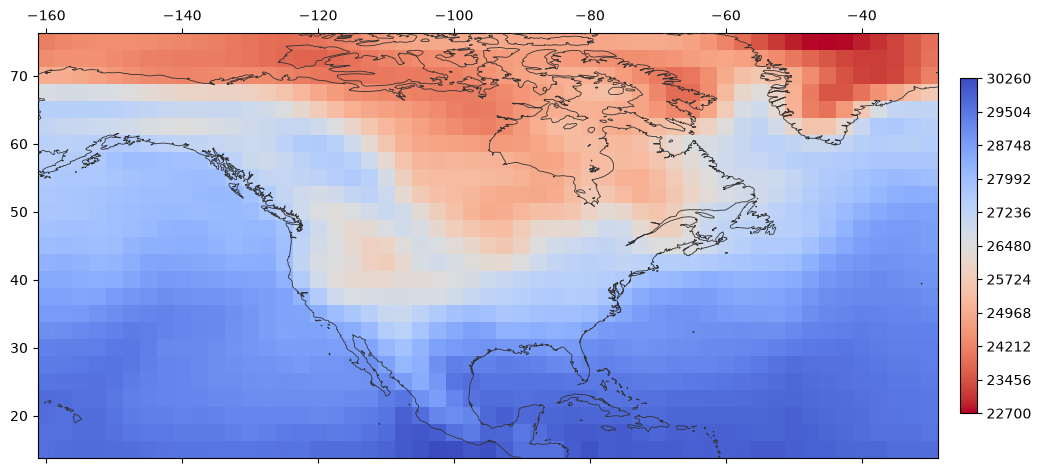

In [5]:
# this COARDS file has no embedded CRS and uses 0..360 longitudes
air0 = nc.get_variable('air')
# read the data and take the first time step (a 2-D lat/lon slice)
air_data = air0.read_array()
air_slice = air_data[0]
# shift the geotransform origin by -360 so the longitudes become -180..180
gt = air0.geotransform
shifted_gt = (gt[0] - 360, gt[1], gt[2], gt[3], gt[4], gt[5])
# rebuild the slice as a georeferenced Dataset (assign EPSG:4326, matching its lon/lat axes)
air_geo = Dataset.create_from_array(air_slice, geo=shifted_gt, epsg=4326)
# plot the georeferenced air-temperature slice in its own lon/lat CRS
glyph = air_geo.plot()
# draw the Natural Earth coastline on top so the geography stays visible over the data
glyph.add_features("coastline", "50m", zorder=5)

**Retrieve the underlying data**

In [6]:
var = nc.get_variable('air')
data = var.read_array()
print('shape:', data.shape)
print(
    'min / mean / max:',
    float(np.nanmin(data)),
    float(np.nanmean(data)),
    float(np.nanmax(data)),
)

shape: (100, 25, 53)
min / mean / max: 22700.0 27317.780233962265 30450.0


**Reduce a dimension** — collapse the time axis to its mean

In [7]:
time_mean = nc.reduce('time', how='mean')
print('dimensions after reducing time:', dict(time_mean.dimension_sizes))

dimensions after reducing time: {'x': 53, 'y': 25}


**Add a variable** — derive a 2-D field and append it as a new variable

In [8]:
work = Path(tempfile.mkdtemp())
slice2d = data[tuple(0 for _ in range(data.ndim - 2))]
NetCDF.create_from_array(
    arr=slice2d,
    geo_ref=GeoReference(geo=var.geotransform, epsg=var.epsg or 4326),
    variable_name='air_slice0',
    path=str(work / 'derived.nc'),
)
nc.add_variable(NetCDF.read_file(str(work / 'derived.nc')), 'air_slice0')
print('variables after add:', nc.variable_names)

variables after add: ['air', 'air_slice0']


**Remove a variable**

In [9]:
nc.remove_variable('air_slice0')
print('variables after remove:', nc.variable_names)

variables after remove: ['air']


**Crop with a real-world polygon** — this COARDS file ships **without an embedded CRS** and uses 0–360 longitudes, so we rebuild one time step as a georeferenced `Dataset` shifted to −180…180 (assigning `EPSG:4326`). That lets us crop to the **contiguous United States** and plot the result in its own lon/lat CRS with the Natural Earth coastline drawn on top; coastline, Gulf and Florida all visible.

cropped air bounds: [np.float64(-123.8), np.float64(26.2), np.float64(-66.2), np.float64(48.8)]


<Axes: >

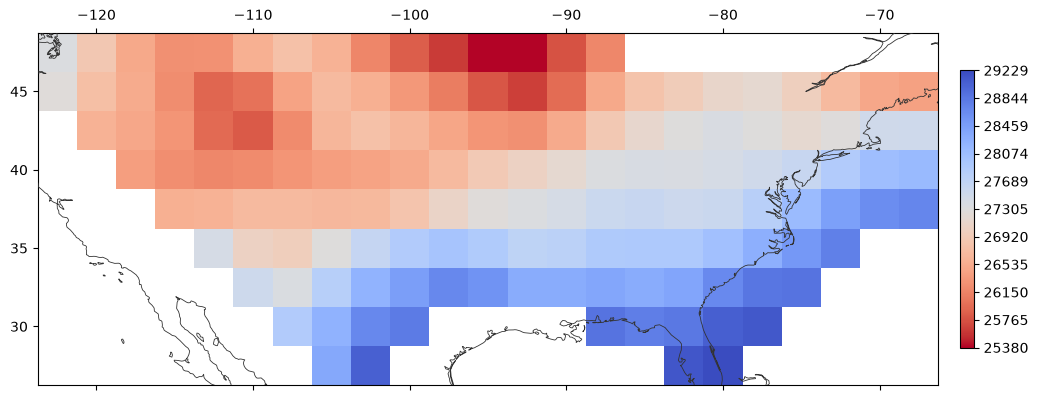

In [10]:
# Contiguous USA, in -180..180 longitudes
usa = Polygon(
    [
        (-125, 49),
        (-102, 49),
        (-80, 47),
        (-66, 45),
        (-66, 38),
        (-77, 30),
        (-80, 25),
        (-90, 30),
        (-98, 30),
        (-105, 25),
        (-112, 33),
        (-122, 42),
        (-125, 49),
    ]
)
aoi = FeatureCollection(gpd.GeoDataFrame(geometry=[usa], crs=4326))

# the file has no embedded CRS + uses 0..360 lons, so shift the geotransform origin by -360
gt = var.geotransform
shifted_gt = (gt[0] - 360, gt[1], gt[2], gt[3], gt[4], gt[5])
# rebuild the first time step as a georeferenced Dataset at -180..180 (EPSG:4326)
air_slice = data[0]
air_geo = Dataset.create_from_array(air_slice, geo=shifted_gt, epsg=4326)
# crop to the USA polygon
cropped = air_geo.crop(aoi)
print('cropped air bounds:', [round(b, 1) for b in cropped.total_bounds])
glyph = cropped.plot()
# draw the Natural Earth coastline on top so the geography stays visible over the data
glyph.add_features("coastline", "50m", zorder=5)

**Save the result** — the cropped field is a single-band raster, written as a GeoTIFF.

In [11]:
out = work / 'air_usa.tif'
cropped.to_file(out)
print('saved cropped raster to', out.name, '->', out.exists())

saved cropped raster to air_usa.tif -> True


## `coards__5v__1d4-4d1__y-desc.nc`

Relative humidity with a vertical level dimension (4-D, packed int16). Longitudes run 0–360.

**Open the file and inspect the container**

In [12]:
nc = NetCDF.read_file(DATA / 'coards__5v__1d4-4d1__y-desc.nc')
nc

Driver: netCDF/Network Common Data Format
Files: ../../../../examples/data/netcdf/samples/coards__5v__1d4-4d1__y-desc.nc
Size is 512, 512
Corner Coordinates:
Upper Left  (    0.0,    0.0)
Lower Left  (    0.0,  512.0)
Upper Right (  512.0,    0.0)
Lower Right (  512.0,  512.0)
Center      (  256.0,  256.0)

**Dimensions and variables**

In [13]:
# get_all_metadata() returns a NetCDFMetadata whose summary lists dimensions and, for each
# variable, its dims / shape / dtype / unit / scale-offset.
meta = nc.get_all_metadata()
print(meta)

NetCDFMetadata
  Driver: netCDF
  Root group: /
  Dimensions (4):
    lat                  size=37
    level                size=4
    lon                  size=72
    time                 size=12
  Variables (5):
    lat dims=('/lat',) shape=(37,) dtype=float32 unit='degrees_north'
    level dims=('/level',) shape=(4,) dtype=float32 unit='millibar'
    lon dims=('/lon',) shape=(72,) dtype=float32 unit='degrees_east'
    rhum dims=('/time', '/level', '/lat', '/lon') shape=(12, 4, 37, 72) dtype=int16 unit='%' scale=0.009999999776482582 offset=302.6600036621094
    time dims=('/time',) shape=(12,) dtype=float64 unit='hours since 1-1-1 00:00:0.0'
  Global attributes: Conventions, title, base_date, history, description, ... (6 total)


**Global attributes**

In [14]:
nc.global_attributes

{'Conventions': 'COARDS',
 'title': 'mean daily NMC reanalysis (2003)',
 'base_date': [2003, 1, 1],
 'history': 'created 03/08/18 by Hoop (netCDF2.3)',
 'description': 'Data is from NMC initialized reanalysis\n(4x/day).  It consists of most variables interpolated to\npressure surfaces from model (sigma) surfaces.',
 'platform': 'Model'}

**Plot the variable** (a 2-D slice is auto-selected for >2-D variables)

<Axes: >

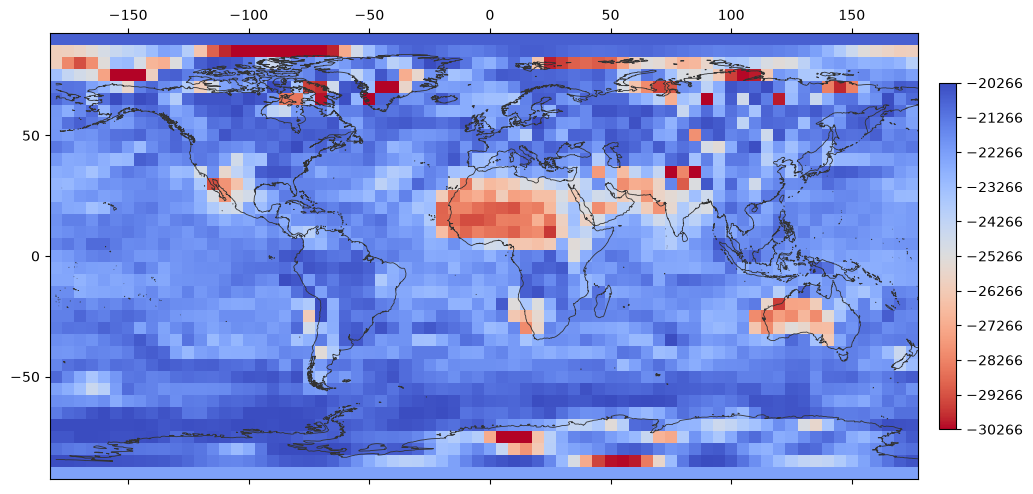

In [15]:
# select the variable to plot
field = nc.get_variable('rhum')
# this grid's longitudes run 0..360; wrap them to -180..180 so it lines up with the coastline
field = field.wrap_longitude()
# plot in the data's own CRS (lon/lat degrees) — no reprojection
glyph = field.plot()
# draw the Natural Earth coastline on top so the geography stays visible over the data
glyph.add_features("coastline", "50m", zorder=5)

**Wrap longitude to −180–180** — this grid spans 0–360 (Pacific-centred). `wrap_longitude` re-frames it to the −180–180 (Greenwich-centred) convention; we wrap the selected variable, then plot the re-centred map.

<Axes: >

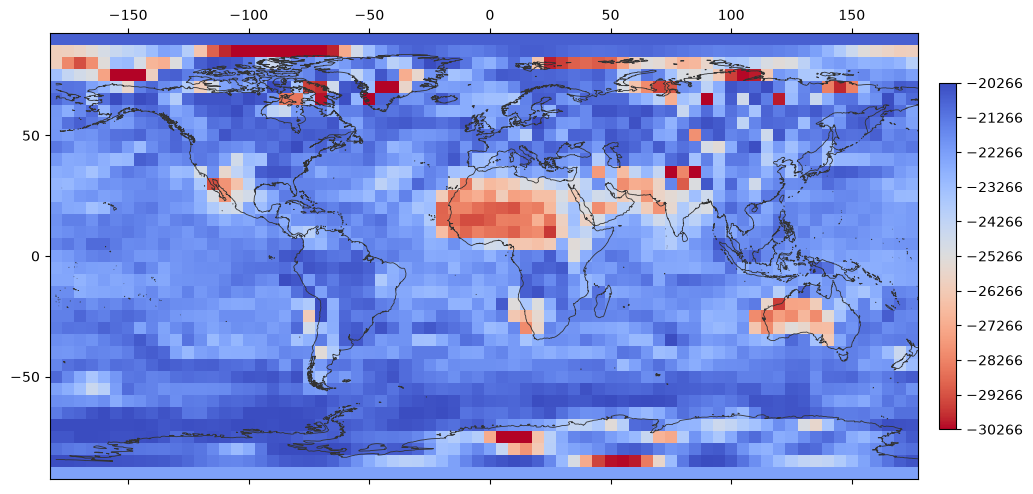

In [16]:
# select the variable to plot
field = nc.get_variable('rhum')
# this grid's longitudes run 0..360; wrap them to -180..180 so it lines up with the coastline
field = field.wrap_longitude()
# plot in the data's own CRS (lon/lat degrees) — no reprojection
glyph = field.plot()
# draw the Natural Earth coastline on top so the geography stays visible over the data
glyph.add_features("coastline", "50m", zorder=5)

**Retrieve the underlying data**

In [17]:
var = nc.get_variable('rhum')
data = var.read_array()
print('shape:', data.shape)
print(
    'min / mean / max:',
    float(np.nanmin(data)),
    float(np.nanmean(data)),
    float(np.nanmax(data)),
)

shape: (48, 37, 72)
min / mean / max: -30266.0 -23468.792831894396 -20266.0


**Reduce a dimension** — collapse the time axis to its mean

In [18]:
time_mean = nc.reduce('time', how='mean')
print('dimensions after reducing time:', dict(time_mean.dimension_sizes))

dimensions after reducing time: {'level': 4, 'x': 72, 'y': 37}


**Add a variable** — derive a 2-D field and append it as a new variable

In [19]:
work = Path(tempfile.mkdtemp())
slice2d = data[tuple(0 for _ in range(data.ndim - 2))]
NetCDF.create_from_array(
    arr=slice2d,
    geo_ref=GeoReference(geo=var.geotransform, epsg=var.epsg or 4326),
    variable_name='rhum_slice0',
    path=str(work / 'derived.nc'),
)
nc.add_variable(NetCDF.read_file(str(work / 'derived.nc')), 'rhum_slice0')
print('variables after add:', nc.variable_names)

variables after add: ['rhum', 'rhum_slice0']


**Remove a variable**

In [20]:
nc.remove_variable('rhum_slice0')
print('variables after remove:', nc.variable_names)

variables after remove: ['rhum']


**Crop with a real-world polygon** — this grid is global and coarse (5°), so we crop to a compact, recognisable continent: **Australia**. `crop` masks every cell outside the polygon to no-data and trims to its bounds; at 5° the continent is blocky but unmistakable. We crop one variable and plot it in its own lon/lat CRS with a coastline overlay, then crop the whole container in native 0-360 coordinates.

cropped rhum bounds: [np.float64(112.5), np.float64(-37.5), np.float64(152.5), np.float64(-12.5)]


<Axes: >

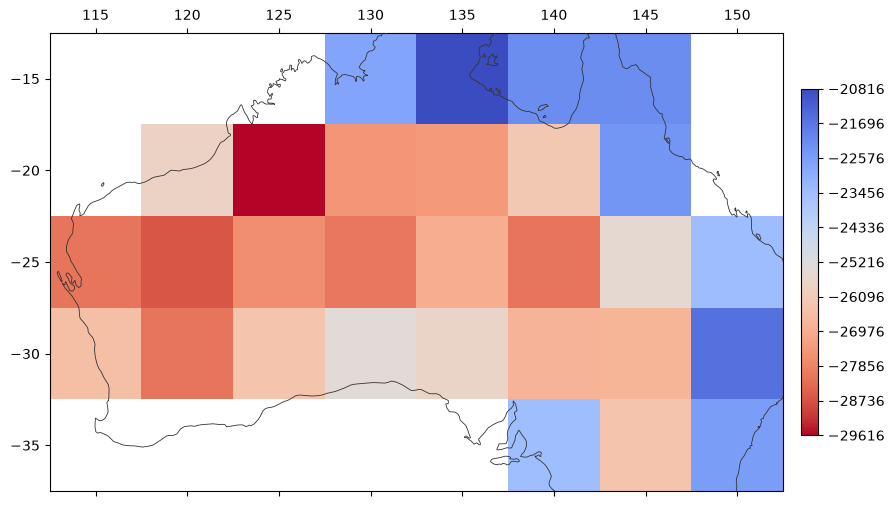

In [21]:
# Australia, lon in the file's native 0-360 convention
australia = Polygon(
    [
        (113, -22),
        (123, -17),
        (130, -12),
        (138, -12),
        (143, -11),
        (147, -19),
        (153, -28),
        (150, -37),
        (141, -38),
        (135, -35),
        (129, -32),
        (123, -34),
        (115, -34),
        (113, -26),
        (113, -22),
    ]
)
aoi = FeatureCollection(gpd.GeoDataFrame(geometry=[australia], crs=var.epsg or 4326))

# select the variable
rhum = nc.get_variable('rhum')
# crop to the Australia polygon (no wrap needed: 113..153 is already valid in -180..180)
rhum_au = rhum.crop(aoi)
print('cropped rhum bounds:', [round(b, 1) for b in rhum_au.total_bounds])
glyph = rhum_au.plot()
# draw the Natural Earth coastline on top so the geography stays visible over the data
glyph.add_features("coastline", "50m", zorder=5)

**Crop the whole container** — clip every variable with the same polygon.

variables in cropped container: ['rhum']


<Axes: >

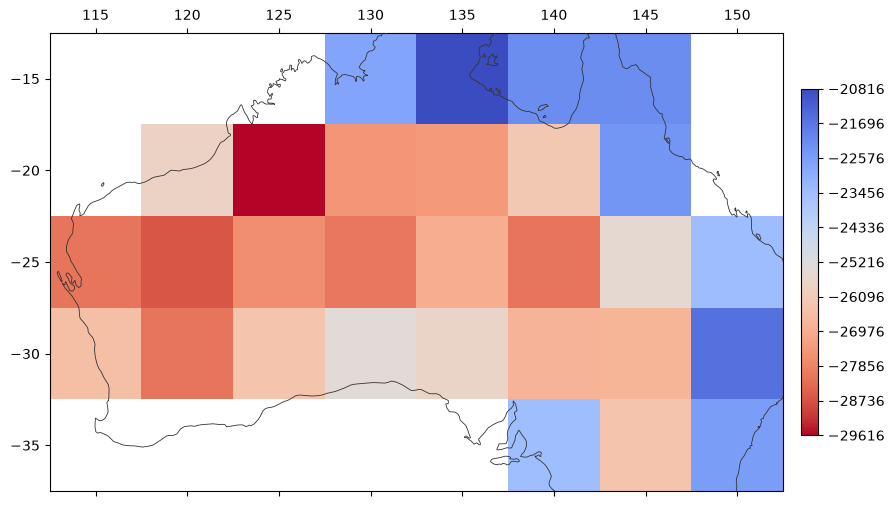

In [22]:
# crop every variable in the container at once (the Australia polygon is valid in 0-360 too)
cropped = nc.crop(aoi)
print('variables in cropped container:', cropped.variable_names)
glyph = rhum_au.plot()
# draw the Natural Earth coastline on top so the geography stays visible over the data
glyph.add_features("coastline", "50m", zorder=5)

**Save the result to a new NetCDF file**

In [23]:
out = work / 'cropped.nc'
cropped.to_file(out)
print('saved cropped container to', out.name, '->', out.exists())

saved cropped container to cropped.nc -> True
